In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

In [2]:
# Global Style Settings
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "figure.dpi": 140,
    "axes.labelpad": 8,
})

COLORS = {
    "purple":     "#534AB7",
    "purple_lt":  "#AFA9EC",
    "teal":       "#1D9E75",
    "teal_lt":    "#9FE1CB",
    "coral":      "#D85A30",
    "coral_lt":   "#F0997B",
    "gray":       "#888780",
    "baseline":   "#444441",
}

RATIO_COLORS = {
    "0.25": COLORS["purple"],
    "0.50": COLORS["teal"],
    "0.75": COLORS["coral"],
}

In [3]:
# Data definition

# Part 1：dummy data, 1 epoch, 3 runs
part1_data = {
    "0.25": [1.0447, 1.0447, 1.0447],
    "0.50": [1.0106, 1.0106, 1.0106],
    "0.75": [1.0274, 1.0274, 1.0274],
}

# Part 2：dummy data, 1 & 5 epochs
part2_data = {
    "baseline":     {"num_steps": 10, "last_loss": 0.6873, "avg_loss": 0.703350, "min_loss": 0.6739, "max_loss": 0.7444},
    "mask_025_e1":  {"num_steps": 10, "last_loss": 0.6924, "avg_loss": 0.705670, "min_loss": 0.6786, "max_loss": 0.7484},
    "mask_05_e1":   {"num_steps": 10, "last_loss": 0.6889, "avg_loss": 0.703780, "min_loss": 0.6747, "max_loss": 0.7456},
    "mask_075_e1":  {"num_steps": 10, "last_loss": 0.6854, "avg_loss": 0.702010, "min_loss": 0.6721, "max_loss": 0.7423},
    "mask_025_e5":  {"num_steps": 50, "last_loss": 0.6614, "avg_loss": 0.671214, "min_loss": 0.6306, "max_loss": 0.7450},
    "mask_05_e5":   {"num_steps": 50, "last_loss": 0.6541, "avg_loss": 0.668916, "min_loss": 0.6278, "max_loss": 0.7418},
    "mask_075_e5":  {"num_steps": 50, "last_loss": 0.6531, "avg_loss": 0.666418, "min_loss": 0.6259, "max_loss": 0.7382},
}

# Part 3：CIFAR-10 subset, 1 epoch
part3_data = {
    "cifar_mask_025_e1": {"num_steps": 125, "last_loss": 0.5203, "avg_loss": 0.709887, "min_loss": 0.3894, "max_loss": 1.1778},
    "cifar_mask_05_e1":  {"num_steps": 180, "last_loss": 0.5263, "avg_loss": 0.750491, "min_loss": 0.4537, "max_loss": 1.3745},
    "cifar_mask_075_e1": {"num_steps": 125, "last_loss": 0.5463, "avg_loss": 0.786324, "min_loss": 0.4755, "max_loss": 1.2228},
}

In [4]:
# figure 1：Part 1 Mask Ratio VS Loss
def plot_part1():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.suptitle("Part 1 — Dummy Data (1 Epoch, 3 Runs Each)", fontsize=13, fontweight="bold", y=1.02)

    ratios = ["0.25", "0.50", "0.75"]
    means  = [np.mean(part1_data[r]) for r in ratios]
    stds   = [np.std(part1_data[r])  for r in ratios]
    colors = [RATIO_COLORS[r] for r in ratios]

    # bar chart
    ax = axes[0]
    bars = ax.bar(ratios, means, color=colors, width=0.5, edgecolor="white",
                  linewidth=0.8, zorder=3)
    ax.errorbar(ratios, means, yerr=stds, fmt="none",
                color="#2C2C2A", capsize=5, linewidth=1.5, capthick=1.5, zorder=4)

    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2, m + 0.003,
                f"{m:.4f}", ha="center", va="bottom", fontsize=9.5, fontweight="500")

    ax.set_xlabel("Mask Ratio")
    ax.set_ylabel("Reconstruction Loss")
    ax.set_title("Mean Loss by Mask Ratio\n(std = 0, fully deterministic)", fontsize=10)
    ax.set_ylim(0.99, 1.06)
    ax.set_xticks(range(len(ratios)))
    ax.set_xticklabels([f"ratio {r}" for r in ratios])

    for bar, r in zip(bars, ratios):
        ax.axhline(y=part1_data[r][0], xmin=(bar.get_x()) / ax.get_xlim()[1],
                   color=RATIO_COLORS[r], linewidth=0, alpha=0)
    ax2 = axes[1]
    for i, r in enumerate(ratios):
        vals = part1_data[r]
        jitter = np.zeros(len(vals))
        offsets = [-0.07, 0, 0.07]
        for j, (v, off) in enumerate(zip(vals, offsets)):
            ax2.scatter(i + off, v, color=RATIO_COLORS[r], s=60,
                        edgecolors="white", linewidth=0.8, zorder=4,
                        label=f"Run {j+1}" if i == 0 else "")
        ax2.hlines(np.mean(vals), i - 0.15, i + 0.15,
                   colors=RATIO_COLORS[r], linewidth=2, zorder=3)

    ax2.set_xticks(range(len(ratios)))
    ax2.set_xticklabels([f"ratio {r}" for r in ratios])
    ax2.set_xlabel("Mask Ratio")
    ax2.set_ylabel("Loss (per run)")
    ax2.set_title("Individual Runs\n(3 runs per ratio, horizontal line = mean)", fontsize=10)
    ax2.set_ylim(0.99, 1.06)
    handles = [mpatches.Patch(color=RATIO_COLORS[r], label=f"ratio {r}") for r in ratios]
    ax2.legend(handles=handles, fontsize=9, framealpha=0.6)

    plt.tight_layout()
    plt.savefig("part1_mask_ratio_loss.png", bbox_inches="tight", dpi=150)
    plt.show()

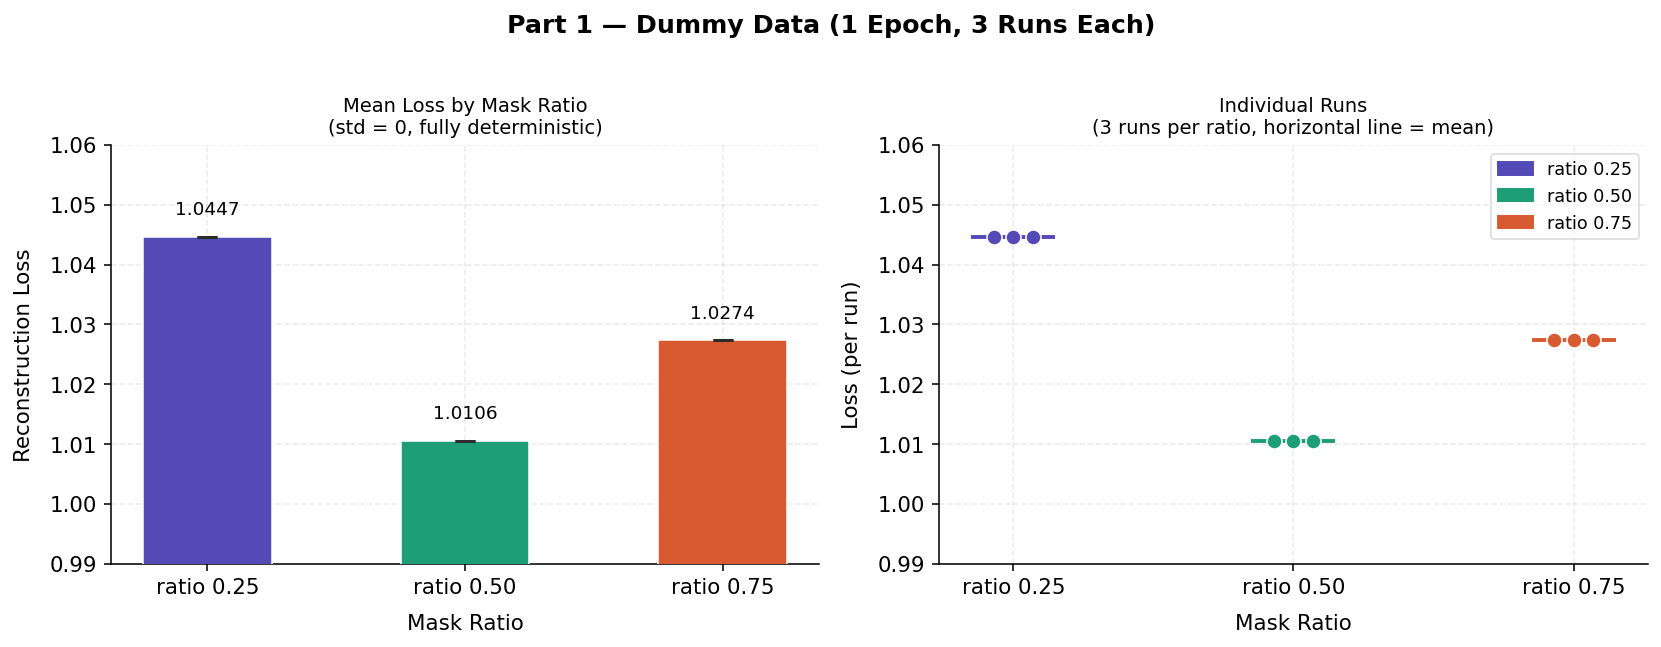

In [5]:
plot_part1()

Part 1 — Effect of Mask Ratio on Dummy Data (1 Epoch, 3 Runs)

Across three repeated runs, the reconstruction loss remained identical for each mask ratio, indicating that the training process is fully deterministic under fixed random seeds.

Among the three configurations, a mask ratio of 0.50 achieved the lowest loss, suggesting that moderate masking provides the most learnable signal for reconstruction on our temporary dummy data. Low masking (0.25) leaves too little for the model to learn from, while high masking (0.75) may over-challenge the reconstructor within a single epoch, both resulting in slightly higher losses.

In [22]:
# figure 2：Part 2 - Epoch VS Mask Ratio

def plot_part2():
    fig = plt.figure(figsize=(14, 5))
    fig.suptitle("Part 2 — Dummy Data: Epoch Count × Mask Ratio Comparison", fontsize=13, fontweight="bold", y=1.02)
    gs = GridSpec(1, 2, figure=fig, wspace=0.35)

    ax1 = fig.add_subplot(gs[0])

    labels_e1 = ["baseline", "0.25 (1e)", "0.50 (1e)", "0.75 (1e)"]
    labels_e5 = ["0.25 (5e)", "0.50 (5e)", "0.75 (5e)"]

    keys_e1   = ["baseline", "mask_025_e1", "mask_05_e1", "mask_075_e1"]
    keys_e5   = ["mask_025_e5", "mask_05_e5", "mask_075_e5"]

    last_e1   = [part2_data[k]["last_loss"] for k in keys_e1]
    last_e5   = [part2_data[k]["last_loss"] for k in keys_e5]
    avg_e1    = [part2_data[k]["avg_loss"]  for k in keys_e1]
    avg_e5    = [part2_data[k]["avg_loss"]  for k in keys_e5]

    x_e1 = np.arange(len(keys_e1))
    x_e5 = np.arange(len(keys_e5))

    width = 0.35
    e1_colors = [COLORS["baseline"], COLORS["purple"], COLORS["teal"], COLORS["coral"]]
    e5_colors = [COLORS["purple_lt"], COLORS["teal_lt"], COLORS["coral_lt"]]

    bars_e1 = ax1.bar(x_e1 - width/2, last_e1, width, color=e1_colors,
                      label="1 epoch (last loss)", edgecolor="white", linewidth=0.6, zorder=3)
    bars_avg_e1 = ax1.bar(x_e1 + width/2, avg_e1, width, color=e1_colors,
                          alpha=0.45, edgecolor="white", linewidth=0.6, zorder=3,
                          hatch="////", label="1 epoch (avg loss)")

    for bar, v in zip(bars_e1, last_e1):
        ax1.text(bar.get_x() + bar.get_width()/2, v + 0.0005,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=7.5)

    for bar, v in zip(bars_avg_e1, avg_e1):
        ax1.text(bar.get_x() + bar.get_width()/2, v + 0.0005,
                f"{v:.4f}", ha="center", va="bottom", fontsize=7.5)

    ax1.axhline(y=part2_data["baseline"]["last_loss"], color=COLORS["baseline"],
                linestyle=":", linewidth=1.2, alpha=0.6, label="baseline last_loss")

    ax1.set_xticks(x_e1)
    ax1.set_xticklabels(labels_e1, fontsize=9)
    ax1.set_ylabel("Loss")
    ax1.set_title("1-Epoch: Last Loss vs Avg Loss", fontsize=10)
    ax1.set_ylim(0.68, 0.76)
    ax1.legend(fontsize=8, framealpha=0.6)

    ax2 = fig.add_subplot(gs[1])

    ratios = [0.25, 0.50, 0.75]
    ll_e1 = [part2_data[k]["last_loss"] for k in keys_e1[1:]]
    ll_e5 = [part2_data[k]["last_loss"] for k in keys_e5]
    al_e1 = [part2_data[k]["avg_loss"]  for k in keys_e1[1:]]
    al_e5 = [part2_data[k]["avg_loss"]  for k in keys_e5]

    ax2.plot(ratios, ll_e1, "o-", color=COLORS["purple"],   linewidth=2, markersize=7,
             label="1 epoch — last_loss")
    ax2.plot(ratios, ll_e5, "s-", color=COLORS["teal"],     linewidth=2, markersize=7,
             label="5 epochs — last_loss")
    ax2.plot(ratios, al_e1, "o--", color=COLORS["purple"],  linewidth=1.2, markersize=5,
             alpha=0.55, label="1 epoch — avg_loss")
    ax2.plot(ratios, al_e5, "s--", color=COLORS["teal"],    linewidth=1.2, markersize=5,
             alpha=0.55, label="5 epochs — avg_loss")

    ax2.fill_between(ratios, ll_e1, ll_e5, alpha=0.10, color=COLORS["teal"],
                     label="improvement gap")

    for r, v1, v5 in zip(ratios, ll_e1, ll_e5):
        delta = v5 - v1
        ax2.annotate(f"Δ{delta:+.4f}", xy=(r, (v1 + v5) / 2),
                     fontsize=8, ha="left", va="center",
                     color=COLORS["teal"],
                     xytext=(r + 0.02, (v1 + v5) / 2))

    ax2.set_xlabel("Mask Ratio")
    ax2.set_ylabel("Loss")
    ax2.set_title("1-Epoch vs 5-Epoch: Loss Trend by Mask Ratio", fontsize=10)
    ax2.set_xticks(ratios)
    ax2.set_xticklabels(["0.25", "0.50", "0.75"])
    ax2.set_ylim(0.645, 0.730)
    ax2.legend(fontsize=8, framealpha=0.6, loc="upper right")

    plt.tight_layout()
    plt.savefig("part2_epoch_mask_comparison.png", bbox_inches="tight", dpi=150)
    plt.show()

/tmp/ipykernel_6538/2013656958.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


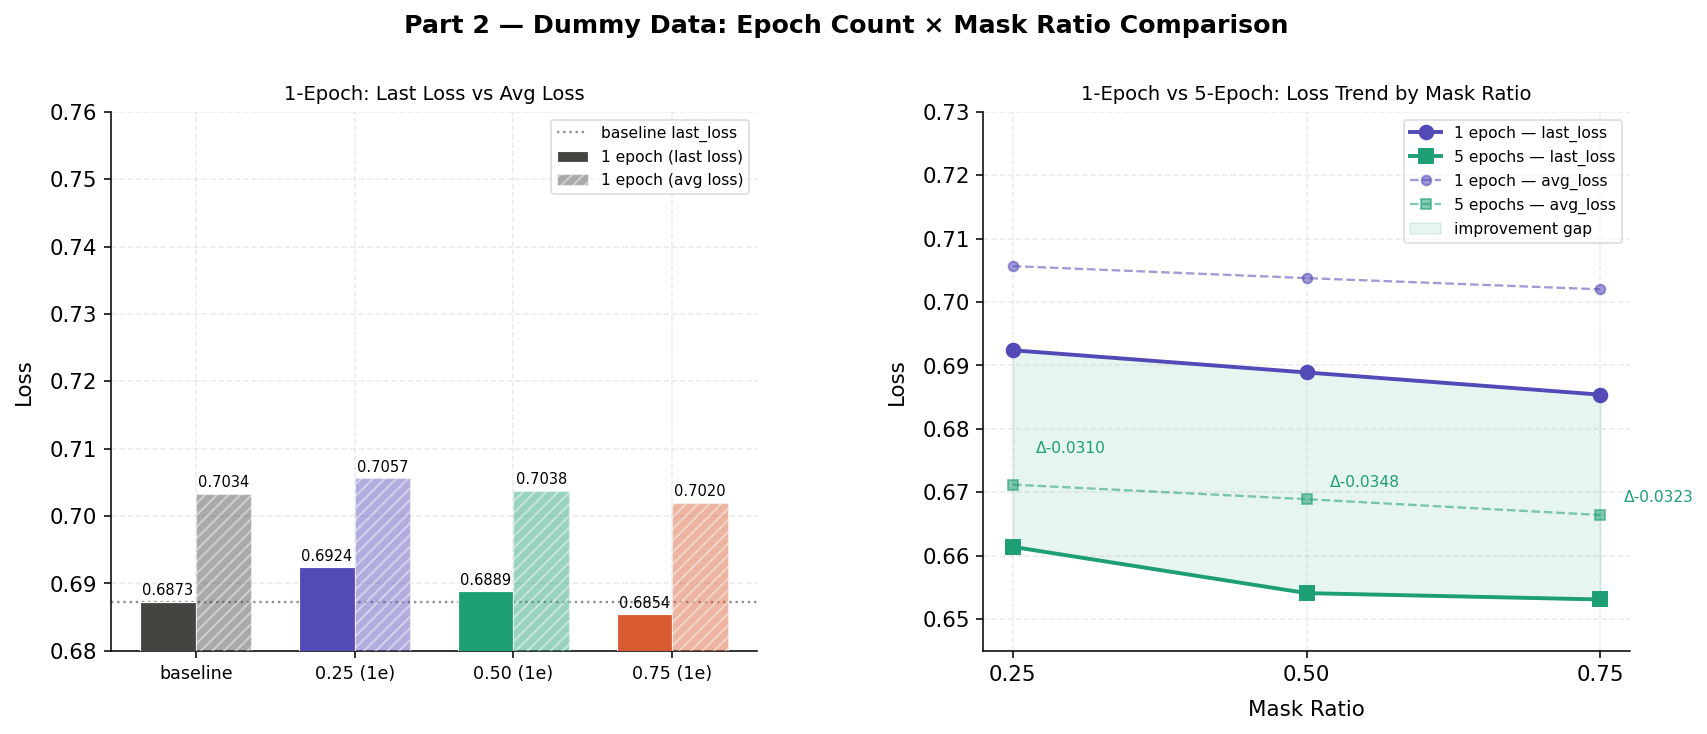

In [23]:
plot_part2()

Part 2 — Impact of Epoch Count and Mask Ratio on Dummy Data

Increasing training from 1 epoch to 5 epochs consistently reduced the final loss across all mask ratios, confirming that the model benefits from extended training even on synthetic data.

The greatest absolute improvement was observed at mask ratio 0.75 (Δ ≈ −0.032), followed by 0.50 (Δ ≈ −0.035) and 0.25 (Δ ≈ −0.031), suggesting that higher masking ratios, while harder to optimize initially, yield proportionally larger gains with more training steps. After 5 epochs, mask ratio 0.75 achieved the lowest last loss (0.6531) among all configurations, indicating that the model increasingly benefits from more challenging reconstruction targets as training progresses. All 5-epoch configurations also fell below the baseline last loss (0.6873), demonstrating meaningful learning beyond the untrained reference.

In [12]:
# figure 3：Part 3 - CIFAR-10 loss distribution analysis
def plot_part3():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Part 3 — CIFAR-10 Subset (1 Epoch): Loss Distribution by Mask Ratio",
                 fontsize=13, fontweight="bold", y=1.02)

    keys   = ["cifar_mask_025_e1", "cifar_mask_05_e1", "cifar_mask_075_e1"]
    ratios = ["0.25", "0.50", "0.75"]
    colors = [RATIO_COLORS[r] for r in ratios]

    last_l = [part3_data[k]["last_loss"] for k in keys]
    avg_l  = [part3_data[k]["avg_loss"]  for k in keys]
    min_l  = [part3_data[k]["min_loss"]  for k in keys]
    max_l  = [part3_data[k]["max_loss"]  for k in keys]
    steps  = [part3_data[k]["num_steps"] for k in keys]

    ax = axes[0]
    y_pos = np.arange(len(ratios))

    for i, (r, c, lo, avg, hi) in enumerate(zip(ratios, colors, min_l, avg_l, max_l)):

        ax.barh(i, hi - lo, left=lo, height=0.4, color=c, alpha=0.25, zorder=2)

        ax.plot([lo, hi], [i, i], color=c, linewidth=2, zorder=3)
        ax.plot(lo,  i, "<", color=c, markersize=9, zorder=4)
        ax.plot(hi,  i, ">", color=c, markersize=9, zorder=4)

        ax.plot(avg, i, "D", color=c, markersize=9, zorder=5,
                markeredgecolor="white", markeredgewidth=1.0)

        ax.plot(last_l[i], i, "o", color=c, markersize=7, zorder=5,
                markeredgecolor="white", markeredgewidth=1.0, alpha=0.7)
        ax.text(lo  - 0.01, i, f"{lo:.4f}",  ha="right", va="center", fontsize=8.5, color=c)
        ax.text(hi  + 0.01, i, f"{hi:.4f}",  ha="left",  va="center", fontsize=8.5, color=c)
        ax.text(avg + 0.00, i + 0.25, f"avg={avg:.4f}", ha="center", fontsize=8, color=c)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"ratio {r}\n({int(s)} steps)" for r, s in zip(ratios, steps)])
    ax.set_xlabel("Reconstruction Loss")
    ax.set_title("Loss Range (min → avg → max)\n◆ = avg_loss   ● = last_loss", fontsize=10)

    handles = [
        mpatches.Patch(color=RATIO_COLORS[r], label=f"ratio {r}") for r in ratios
    ]
    ax.legend(handles=handles, fontsize=9, loc="lower right", framealpha=0.6)

    ax2 = axes[1]
    x    = np.arange(len(ratios))
    w    = 0.18
    metrics = {
        "last_loss": (last_l, "solid",   1.0,  "Last loss"),
        "avg_loss":  (avg_l,  "////",    0.75, "Avg loss"),
        "min_loss":  (min_l,  "\\\\\\\\", 0.55, "Min loss"),
        "max_loss":  (max_l,  "....",    0.40, "Max loss"),
    }

    offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]
    for (name, (vals, hatch, alpha, label)), offset in zip(metrics.items(), offsets):
        bars = ax2.bar(x + offset, vals, w, color=colors,
                       alpha=alpha, edgecolor="white", linewidth=0.6,
                       hatch=hatch if hatch != "solid" else "", zorder=3,
                       label=label)

    ax2.set_xticks(x)
    ax2.set_xticklabels([f"ratio {r}" for r in ratios])
    ax2.set_ylabel("Loss")
    ax2.set_title("All Loss Metrics by Mask Ratio\n(CIFAR-10, 1 epoch)", fontsize=10)

    from matplotlib.patches import Patch
    legend_elems = [
        Patch(facecolor="gray", alpha=1.0, label="last_loss"),
        Patch(facecolor="gray", alpha=0.75, hatch="////", label="avg_loss"),
        Patch(facecolor="gray", alpha=0.55, hatch="\\\\\\\\", label="min_loss"),
        Patch(facecolor="gray", alpha=0.40, hatch="....", label="max_loss"),
    ]
    color_elems = [Patch(facecolor=RATIO_COLORS[r], label=f"ratio {r}") for r in ratios]
    ax2.legend(handles=legend_elems + color_elems, fontsize=8.5,
               framealpha=0.6, ncol=2, loc="upper left")

    plt.tight_layout()
    plt.savefig("part3_cifar10_loss_distribution.png", bbox_inches="tight", dpi=150)
    plt.show()

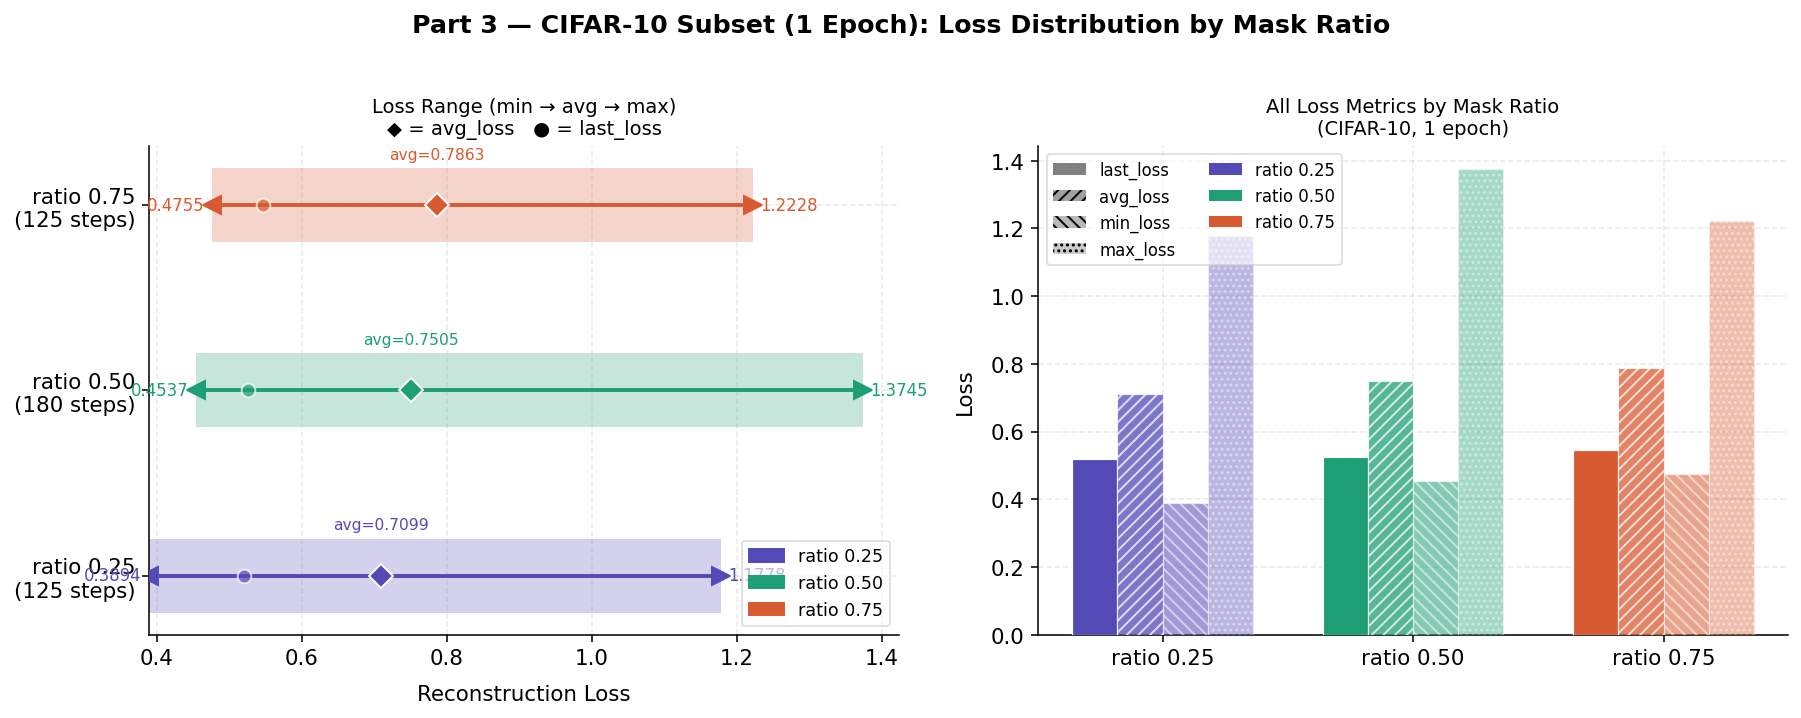

In [13]:
    plot_part3()

Part 3 — Performance on CIFAR-10 Subset (1 Epoch)

On the CIFAR-10 subset, all three mask ratios achieved substantially lower last loss values compared to dummy data experiments, reflecting the richer structural information present in natural images that facilitates more effective self-supervised learning.

However, the average loss across training steps was considerably higher (0.71–0.79), and the loss range was wide (min ≈ 0.39–0.48, max ≈ 1.18–1.37), indicating high training volatility during the first epoch. Higher mask ratios were associated with greater average loss and wider loss ranges, consistent with the increased difficulty of reconstructing larger masked regions. Notably, mask ratio 0.50 required the most training steps (180 vs. 125 for the others), yet still converged to a comparable last loss, suggesting it may explore a broader loss landscape before stabilizing.

In [10]:
# figure 4：dummy vs CIFAR-10
def plot_summary():
    fig, ax = plt.subplots(figsize=(11, 5))
    fig.suptitle("Summary — Last Loss Comparison Across All Experiments",
                 fontsize=13, fontweight="bold")

    groups = {
        "Dummy\n(1e)":   ["mask_025_e1", "mask_05_e1", "mask_075_e1"],
        "Dummy\n(5e)":   ["mask_025_e5", "mask_05_e5", "mask_075_e5"],
    }
    cifar_keys = ["cifar_mask_025_e1", "cifar_mask_05_e1", "cifar_mask_075_e1"]

    x_pos   = []
    heights = []
    bar_colors = []
    tick_labels = []
    tick_pos    = []

    cursor = 0
    for group_name, keys in groups.items():
        group_center = cursor + 1
        for r, k in zip(["0.25", "0.50", "0.75"], keys):
            x_pos.append(cursor)
            heights.append(part2_data[k]["last_loss"])
            bar_colors.append(RATIO_COLORS[r])
            cursor += 1
        tick_labels.append(group_name)
        tick_pos.append(group_center)
        cursor += 1  # gap

    # baseline
    ax.axhline(y=part2_data["baseline"]["last_loss"], color=COLORS["baseline"],
               linewidth=1.2, linestyle="--", alpha=0.7, label="baseline (dummy, 1e)")

    # dummy bars
    bars = ax.bar(x_pos, heights, color=bar_colors, width=0.7,
                  edgecolor="white", linewidth=0.6, zorder=3)
    for bar, v in zip(bars, heights):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.0005,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)

    # CIFAR-10 bars
    cifar_x = [cursor, cursor + 1, cursor + 2]
    cifar_vals = [part3_data[k]["last_loss"] for k in cifar_keys]
    cifar_colors = [RATIO_COLORS[r] for r in ["0.25", "0.50", "0.75"]]
    cifar_bars = ax.bar(cifar_x, cifar_vals, color=cifar_colors, width=0.7,
                        edgecolor="white", linewidth=0.6, zorder=3, alpha=0.65,
                        hatch="////")
    for bar, v in zip(cifar_bars, cifar_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)
    tick_labels.append("CIFAR-10\n(1e)")
    tick_pos.append(cursor + 1)

    ratio_patches = [mpatches.Patch(color=RATIO_COLORS[r], label=f"mask ratio {r}") for r in ["0.25", "0.50", "0.75"]]
    dataset_patches = [
        mpatches.Patch(facecolor="gray", alpha=1.0, label="dummy data (solid)"),
        mpatches.Patch(facecolor="gray", alpha=0.65, hatch="////", label="CIFAR-10 (hatched)"),
    ]
    ax.legend(handles=ratio_patches + dataset_patches, fontsize=9, framealpha=0.6, ncol=2)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_ylabel("Last Loss")
    ax.set_title("", fontsize=10)
    ax.set_ylim(0.49, 0.74)

    plt.tight_layout()
    plt.savefig("summary_cross_experiment.png", bbox_inches="tight", dpi=150)
    plt.show()

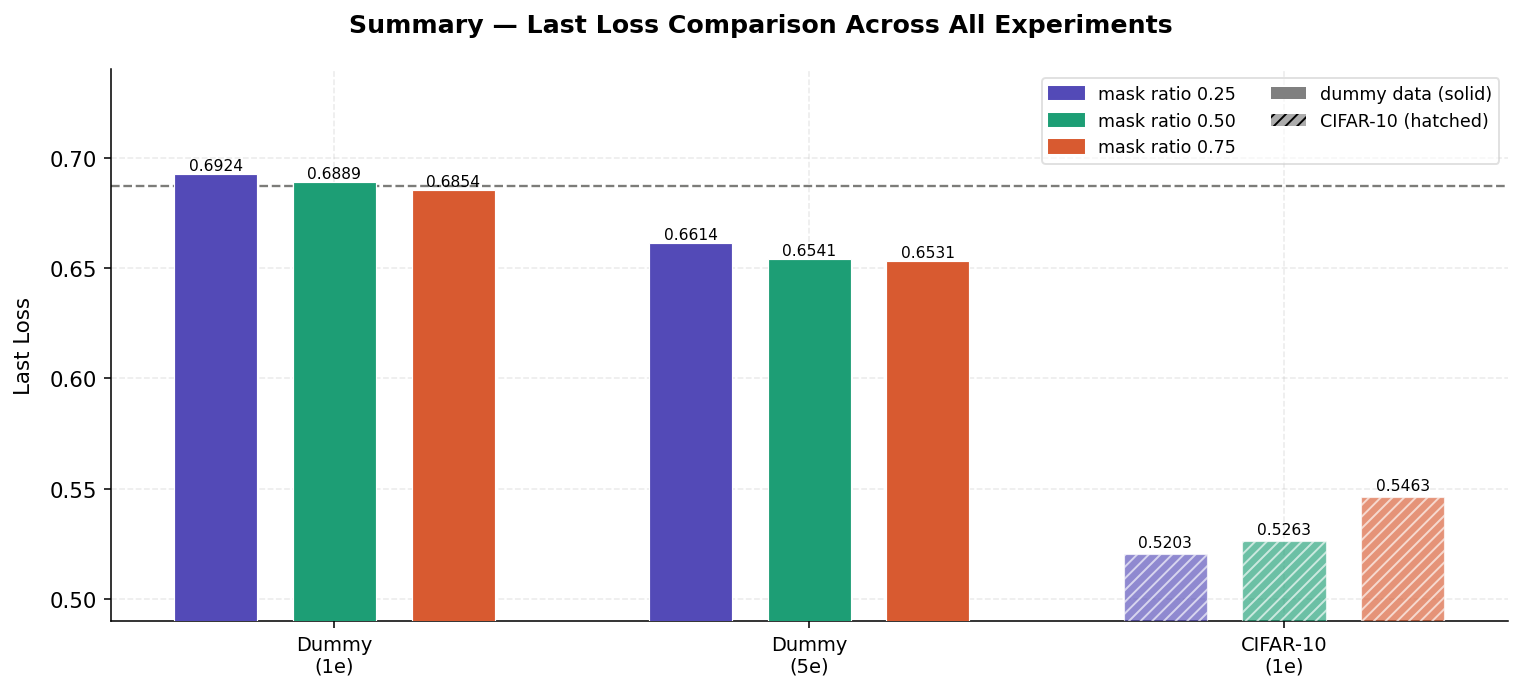

In [11]:
    plot_summary()

Overall Summary

Across all experiments, mask ratio 0.50 demonstrates a consistent balance between reconstruction difficulty and convergence speed, performing well in both the 1-epoch dummy setting and the CIFAR-10 setting. Mask ratio 0.75 shows the strongest improvement under extended training, making it a promising configuration when more compute is available. The stark contrast between dummy data and CIFAR-10 results highlights the importance of data complexity in shaping the training dynamics of masked image modeling.
